# Translation to Strategy: The Central Conversion Story

**Docker image**: `ml4t`

The IC-to-Sharpe gap is the central narrative of Ch16-20. Ch16 introduced
the concept with individual examples; this notebook shows the **full 9-CS
picture including holdout**. It also covers entry/cadence/horizon effects
and selectivity — the IC-to-Sharpe translation story (allocator choice
is taken up in §05).

This is one of the few analyses that appears in both Ch16 (introduction)
and Ch20 (full picture with holdout). The framing: **IC translates into
Sharpe only through implementation.**

**Learning Objectives**:
- See the full IC-to-Sharpe translation across 9 case studies
- Compare validation and holdout Sharpe (does the translation persist?)
- Understand which implementation factors mediate conversion

**Book Reference**: Chapter 20, Section 20.4 (From signals to strategies)

**Prerequisites**: Run [`01_aggregate_synthesis`](01_aggregate_synthesis.ipynb) first.

In [1]:
"""Ch20 Translation to Strategy — IC-to-Sharpe gap with holdout closure."""

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

from utils.paths import get_chapter_dir
from utils.style import show_with_alt

In [2]:
MAX_SYMBOLS = 0

In [3]:
OUTPUT_DIR = get_chapter_dir(20) / "output"

DISPLAY_NAMES = {
    "etfs": "ETFs",
    "crypto_perps_funding": "Crypto",
    "nasdaq100_microstructure": "NASDAQ-100",
    "sp500_equity_option_analytics": "S&P 500 Eq+Opt",
    "us_firm_characteristics": "US Firms",
    "fx_pairs": "FX Pairs",
    "cme_futures": "CME Futures",
    "sp500_options": "S&P 500 Options",
    "us_equities_panel": "US Equities",
}

## Load Data

In [4]:
variant_df = pl.read_parquet(OUTPUT_DIR / "variant_analysis.parquet")
bt_df = pl.read_parquet(OUTPUT_DIR / "backtest_comparison.parquet")
ic_df = pl.read_parquet(OUTPUT_DIR / "ic_comparison.parquet")
holdout_df = pl.read_parquet(OUTPUT_DIR / "holdout_results.parquet")
mq_df = pl.read_parquet(OUTPUT_DIR / "measurement_quality.parquet")
synthesis = json.load((OUTPUT_DIR / "all_synthesis.json").open())

print(f"Variants: {len(variant_df)} across {variant_df['case_study'].n_unique()} case studies")
print(f"Holdout configurations: {holdout_df.height}")

Variants: 429 across 9 case studies
Holdout configurations: 8


## IC vs Sharpe: What the Holdout Shows

Ch16 shows the IC-to-Sharpe translation on validation data. What this notebook
adds is the holdout, and the comparison has to be made carefully.

An earlier version of this figure put a validation IC and a holdout IC on the
same axis. They are not the same measurement. The validation number available
in the artifacts is the maximum IC over a whole hyperparameter sweep; the
holdout number is the IC of the one prediction that was selected. A
maximum over dozens of draws sits above the typical draw by construction, so
every arrow drawn between the two pointed left whether or not anything decayed.
The figure manufactured the decay it was meant to measure.

Two panels instead, each comparing like with like. The left panel is the
IC-to-Sharpe translation measured entirely on the holdout, with the intervals
the registry stores for both quantities. The right panel is validation Sharpe
against holdout Sharpe for the same selected configuration, which is where a
decay claim can be made.

In [5]:
selected = holdout_df.join(
    mq_df.select("cs_id", "rank1_val_sharpe"), on="cs_id", how="left"
).with_columns(label_name=pl.col("cs_id").replace_strict(DISPLAY_NAMES, default=pl.col("cs_id")))

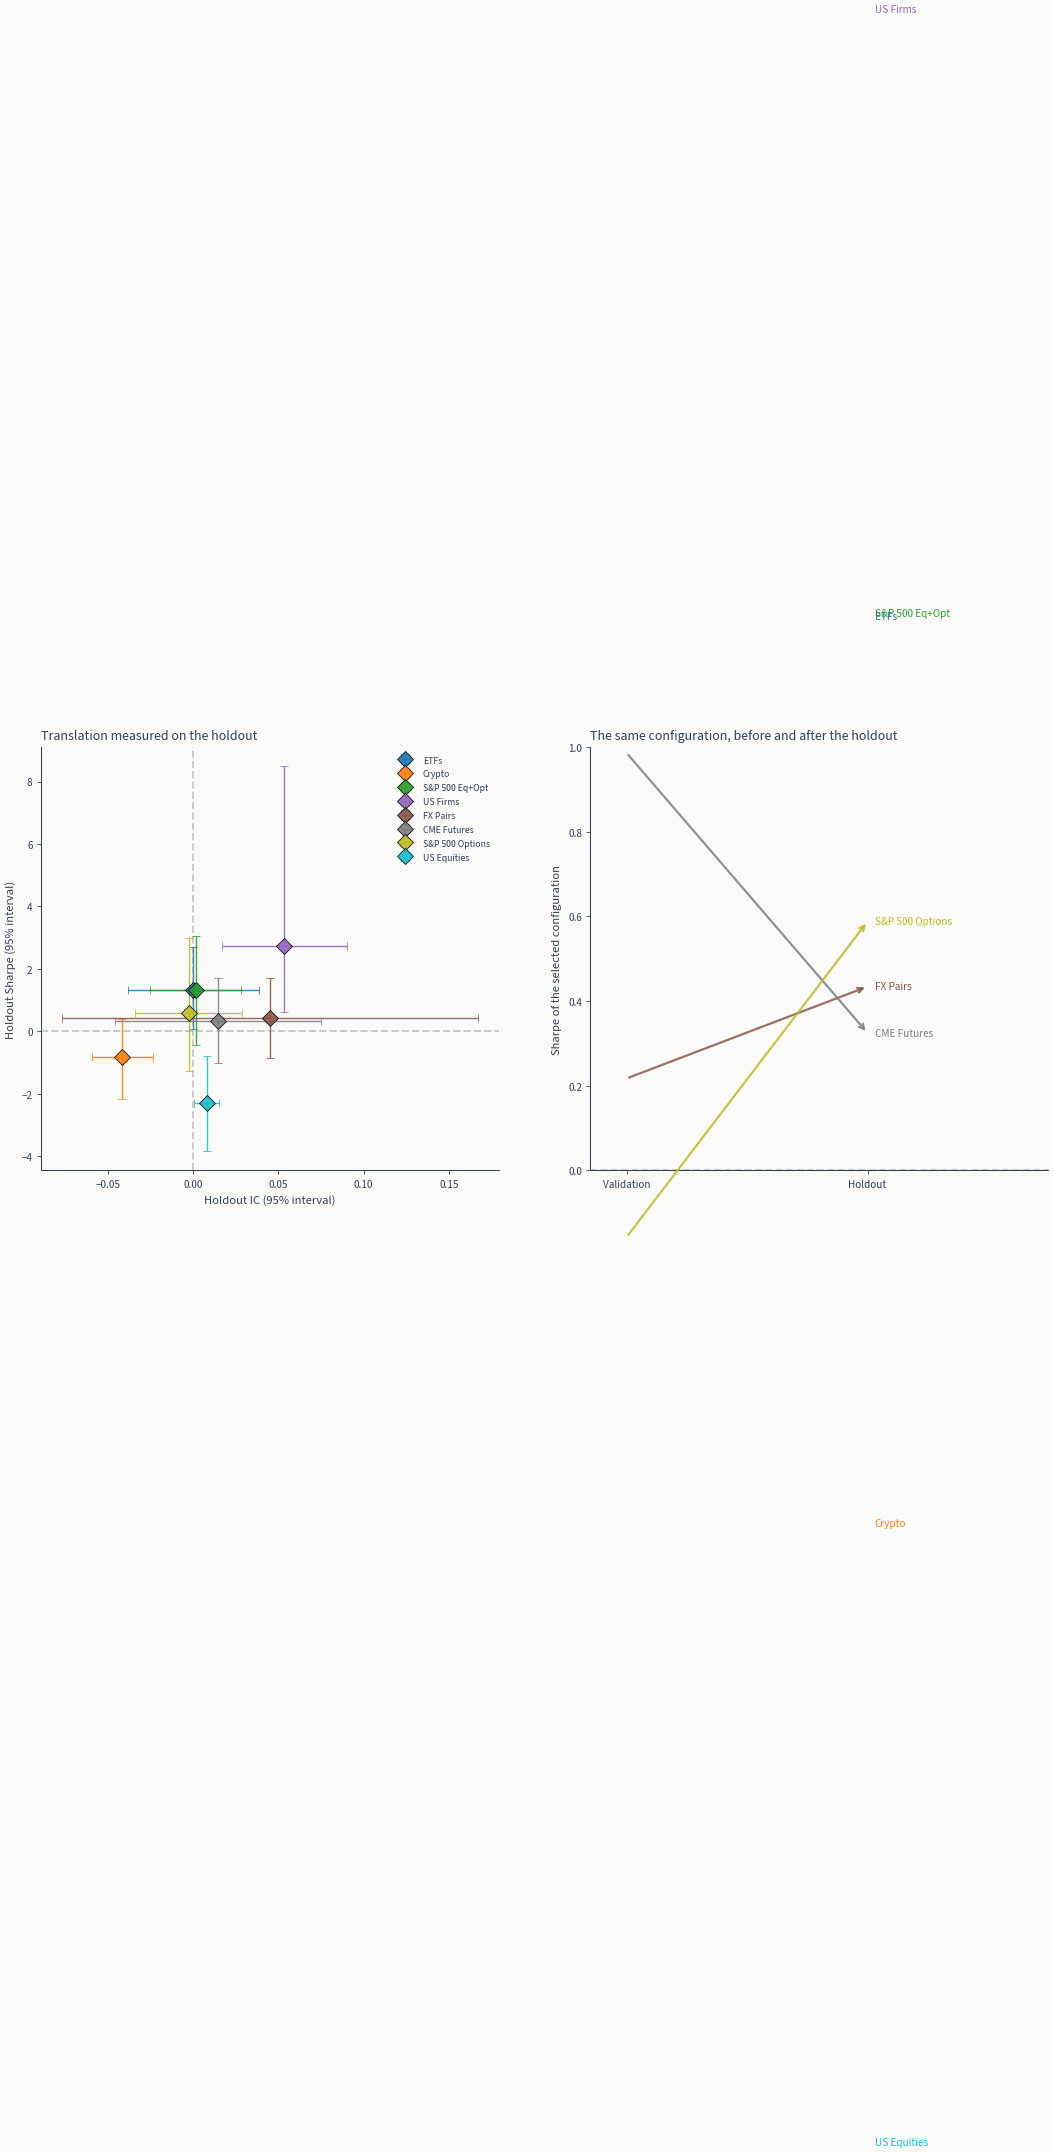

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colors = plt.cm.tab10(np.linspace(0, 1, max(selected.height, 1)))

ax = axes[0]
for i, row in enumerate(selected.iter_rows(named=True)):
    ax.errorbar(
        row["holdout_ic"],
        row["holdout_sharpe"],
        xerr=[
            [row["holdout_ic"] - row["holdout_ic_ci_lo"]],
            [row["holdout_ic_ci_hi"] - row["holdout_ic"]],
        ]
        if row["holdout_ic_ci_lo"] is not None
        else None,
        yerr=[
            [row["holdout_sharpe"] - row["holdout_sharpe_ci_lo"]],
            [row["holdout_sharpe_ci_hi"] - row["holdout_sharpe"]],
        ]
        if row["holdout_sharpe_ci_lo"] is not None
        else None,
        fmt="D",
        color=colors[i],
        markersize=8,
        markeredgecolor="black",
        markeredgewidth=0.6,
        elinewidth=1,
        capsize=3,
        alpha=0.9,
        label=row["label_name"],
    )
ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.axvline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("Holdout IC (95% interval)")
ax.set_ylabel("Holdout Sharpe (95% interval)")
ax.set_title("Translation measured on the holdout")
ax.legend(fontsize=7, loc="best")

ax = axes[1]
_paired = selected.filter(
    pl.col("rank1_val_sharpe").is_not_null() & pl.col("holdout_sharpe").is_not_null()
)
for i, row in enumerate(_paired.iter_rows(named=True)):
    ax.annotate(
        "",
        xy=(1, row["holdout_sharpe"]),
        xytext=(0, row["rank1_val_sharpe"]),
        arrowprops={"arrowstyle": "->", "color": colors[i], "lw": 1.6, "alpha": 0.85},
    )
    ax.text(
        1.03,
        row["holdout_sharpe"],
        row["label_name"],
        fontsize=8,
        va="center",
        color=colors[i],
    )
ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlim(-0.15, 1.75)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Validation", "Holdout"])
ax.set_ylabel("Sharpe of the selected configuration")
ax.set_title("The same configuration, before and after the holdout")

show_with_alt(
    fig,
    "Left: holdout IC against holdout Sharpe for each selected configuration, "
    "with 95 percent intervals on both axes; the intervals are wide enough that "
    "most points are not separated from zero. Right: arrows from each case "
    "study's validation Sharpe to its holdout Sharpe for the same configuration.",
)

In [7]:
_up = _paired.filter(pl.col("holdout_sharpe") > pl.col("rank1_val_sharpe")).height
_ic_pos = selected.filter(pl.col("holdout_ic_ci_lo") > 0).height
_sh_pos = selected.filter(pl.col("holdout_sharpe_ci_lo") > 0).height
display(
    Markdown(
        f"{selected.height} case studies reached the holdout. Of those, "
        f"{_ic_pos} {'has' if _ic_pos == 1 else 'have'} a holdout IC whose 95 "
        f"percent interval lies entirely above zero, and {_sh_pos} "
        f"{'has' if _sh_pos == 1 else 'have'} a holdout Sharpe whose interval "
        "does. "
        f"Of the {_paired.height} with a validation Sharpe to compare against, "
        f"{_up} came out higher on the holdout than on validation and "
        f"{_paired.height - _up} came out lower.\n\n"
        "Sharpe moving in both directions is what selection noise looks like. "
        "The intervals are the reason to be careful here: a configuration can move a "
        "long way between the two splits without that movement being "
        "distinguishable from the width of either estimate."
    )
)

8 case studies reached the holdout. Of those, 2 have a holdout IC whose 95 percent interval lies entirely above zero, and 2 have a holdout Sharpe whose interval does. Of the 8 with a validation Sharpe to compare against, 3 came out higher on the holdout than on validation and 5 came out lower.

Sharpe moving in both directions is what selection noise looks like. The intervals are the reason to be careful here: a configuration can move a long way between the two splits without that movement being distinguishable from the width of either estimate.

## Where the IC-leading and Sharpe-leading families diverge

The family with the highest mean IC need not be the family whose backtest
posts the highest Sharpe. IC scores the ordering of predictions; Sharpe scores
what a portfolio built from that ordering actually earned after the entry
scheme, the position sizing, the rebalancing cadence and the costs had their
say. The comparison below asks how often the two agree.

It can only be asked where both exist. Four case studies have registered
predictions but no backtests, so they have an IC leader and no Sharpe leader.
They are shown, and excluded from the count, rather than being scored as
disagreements - an earlier version compared the IC leader against an empty
string and recorded four "No" rows on that basis.

In [8]:
_ic_leaders = (
    ic_df.filter(pl.col("ic_mean").is_not_null())
    .sort("ic_mean", descending=True)
    .group_by("case_study")
    .first()
    .select("case_study", ic_leader="family", ic_lead_value="ic_mean")
)
_sharpe_leaders = pl.DataFrame(
    [
        {
            "case_study": DISPLAY_NAMES.get(cs, cs),
            "sharpe_leader": (
                data["pipeline_summary"].get("backtest", {}).get("best_source", "") or ""
            ).split("/")[0]
            or None,
            "val_sharpe": data["pipeline_summary"].get("backtest", {}).get("ml_sharpe"),
        }
        for cs, data in synthesis.items()
    ]
)
leader_df = (
    _ic_leaders.join(_sharpe_leaders, on="case_study", how="full", coalesce=True)
    .join(
        holdout_df.select("case_study", "holdout_sharpe"),
        on="case_study",
        how="left",
    )
    .with_columns(
        agree=pl.when(pl.col("sharpe_leader").is_null())
        .then(pl.lit("no backtest"))
        .when(pl.col("ic_leader") == pl.col("sharpe_leader"))
        .then(pl.lit("yes"))
        .otherwise(pl.lit("no"))
    )
    .sort("ic_lead_value", descending=True, nulls_last=True)
)
leader_df

case_study,ic_leader,ic_lead_value,sharpe_leader,val_sharpe,holdout_sharpe,agree
str,str,f64,str,f64,f64,str
"""US Firms""","""gbm""",0.061869,"""gbm""",3.5573,2.74223,"""yes"""
"""ETFs""","""latent_factors""",0.037058,"""gbm""",0.7398,1.30955,"""no"""
"""US Equities""","""gbm""",0.023885,"""gbm""",1.0528,-2.294157,"""yes"""
"""Crypto""","""gbm""",0.020113,"""linear""",1.5556,-0.83214,"""no"""
"""CME Futures""","""latent_factors""",0.011125,"""latent_factors""",0.9858,0.324444,"""yes"""
"""NASDAQ-100""","""ensemble""",0.00775,"""deep_learning""",2.3001,null,"""no"""
"""S&P 500 Eq+Opt""","""tabular_dl""",0.005388,"""gbm""",1.6003,1.316705,"""no"""
"""S&P 500 Options""","""tabular_dl""",0.00156,"""gbm""",-0.1576,0.587897,"""no"""
"""FX Pairs""","""tabular_dl""",0.000096,"""deep_learning""",0.2172,0.434173,"""no"""


In [9]:
_comparable = leader_df.filter(pl.col("agree") != "no backtest")
_agreed = _comparable.filter(pl.col("agree") == "yes")
display(
    Markdown(
        f"Of {leader_df.height} case studies, {_comparable.height} have both an "
        f"IC leader and a Sharpe leader. They name the same family in "
        f"{_agreed.height} of those"
        + (f" ({', '.join(_agreed['case_study'].to_list())})" if _agreed.height else "")
        + f" and different families in {_comparable.height - _agreed.height}. "
        f"The remaining {leader_df.height - _comparable.height} have no "
        "registered backtests and cannot answer the question either way."
    )
)

Of 9 case studies, 9 have both an IC leader and a Sharpe leader. They name the same family in 3 of those (US Firms, US Equities, CME Futures) and different families in 6. The remaining 0 have no registered backtests and cannot answer the question either way.

With this many comparable case studies, the count settles nothing on its own.
What it does show is that agreement is not automatic: the ordering a model
produces and the return a portfolio built on that ordering earns are separated
by everything the implementation does in between. That is the reason the
pipeline runs the backtest stage at all rather than selecting on IC and
stopping, and it is why a model comparison reported only in IC leaves the
question of what to trade open.

## Cadence

Rebalancing cadence sets how much friction a signal has to overcome. A
15-minute strategy turns its book over orders of magnitude more often than a
daily one, and a daily one many times more than a monthly one, so the same
per-period edge nets out very differently depending on how long a position is
held.

That is the mechanism. Whether the numbers below demonstrate it is a separate
question, and they do not: each cadence in this panel is carried by a different
set of case studies, so a cadence difference and a case-study difference are
the same difference. The table is a description of what was run.

In [10]:
cadence_stats = (
    variant_df.filter(pl.col("sharpe").is_not_null())
    .group_by("cadence")
    .agg(
        n_variants=pl.len(),
        n_case_studies=pl.col("case_study").n_unique(),
        median_sharpe=pl.col("sharpe").median().round(3),
        mean_sharpe=pl.col("sharpe").mean().round(3),
        pct_positive=((pl.col("sharpe") > 0).sum() / pl.len() * 100).round(1),
    )
    .sort("median_sharpe", descending=True)
)

### Signal Sharpe by rebalancing cadence

In [11]:
cadence_stats

cadence,n_variants,n_case_studies,median_sharpe,mean_sharpe,pct_positive
str,u32,u32,f64,f64,f64
"""monthly""",50,1,0.803,1.259,100.0
"""daily""",288,6,0.174,-0.054,57.6
"""8h""",49,1,-1.155,-0.942,22.4
"""15min""",35,1,-6.292,-5.315,34.3


In [12]:
_backtested = variant_df.filter(pl.col("sharpe").is_not_null())
_by_cad = (
    _backtested.group_by("cadence")
    .agg(n_cs=pl.col("case_study").n_unique(), cs=pl.col("case_study").unique())
    .sort("n_cs", descending=True)
)
_no_bt = sorted(set(variant_df["cadence"].unique()) - set(_backtested["cadence"].unique()))
display(
    Markdown(
        "Cadences with backtested variants: "
        + "; ".join(
            f"**{r['cadence']}** ({r['n_cs']} case "
            f"{'study' if r['n_cs'] == 1 else 'studies'}: {', '.join(sorted(r['cs']))})"
            for r in _by_cad.iter_rows(named=True)
        )
        + ". "
        + (
            f"No variant at {', '.join(_no_bt)} cadence has a registered "
            "backtest, so the higher-frequency end of the comparison is absent "
            "rather than weak. "
            if _no_bt
            else ""
        )
        + "Any cadence represented by a single case study cannot be separated "
        "from that case study, and the median Sharpe attributed to it is that "
        "case study's median."
    )
)

Cadences with backtested variants: **daily** (6 case studies: CME Futures, ETFs, FX Pairs, S&P 500 Eq+Opt, S&P 500 Options, US Equities); **monthly** (1 case study: US Firms); **15min** (1 case study: NASDAQ-100); **8h** (1 case study: Crypto). Any cadence represented by a single case study cannot be separated from that case study, and the median Sharpe attributed to it is that case study's median.

## Signal Sharpe Distribution per Case Study

The highest Sharpe per case study says nothing about what the rest of the sweep
did. A configuration selected as the maximum of a large sample is drawn from
the upper tail of that sample, and how far into the tail it sits depends on how
many configurations were tried and how dispersed they were. The box plot below
shows the distribution each maximum was drawn from.

This is the multiple-testing problem the Deflated Sharpe Ratio addresses by
discounting a maximum for the number of trials behind it. This notebook does
not compute a DSR; it shows the distribution that a DSR would be computed
against. Only case studies with registered backtests appear.

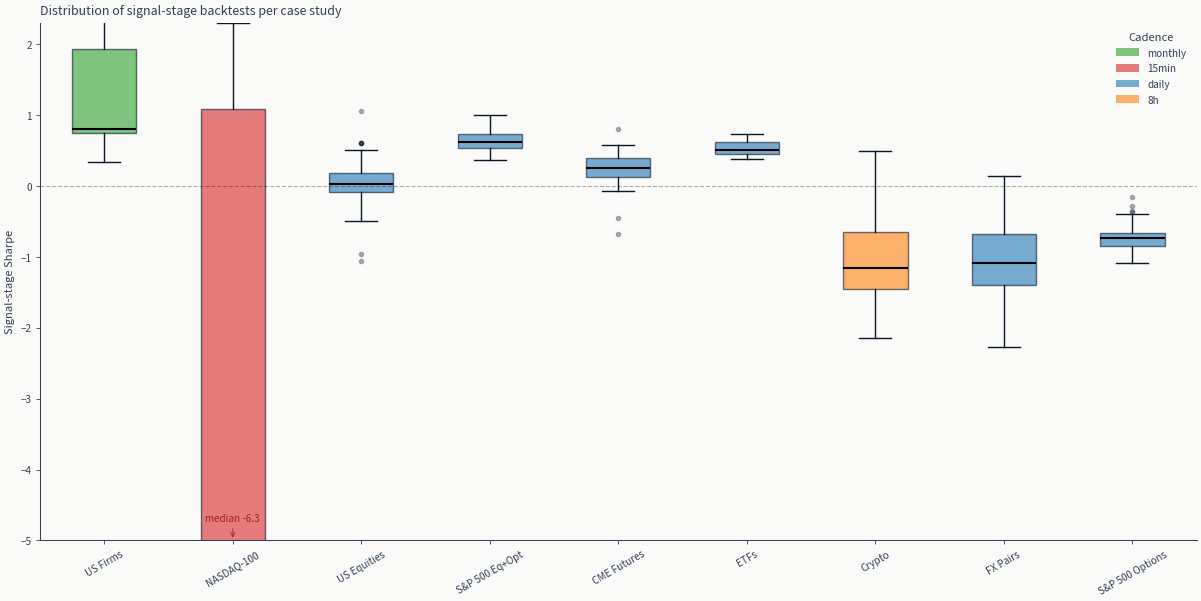

In [13]:
cadence_colors = {
    "15min": "#d62728",
    "8h": "#ff7f0e",
    "daily": "#1f77b4",
    "monthly": "#2ca02c",
}

cs_order = (
    variant_df.filter(pl.col("sharpe").is_not_null())
    .group_by("case_study")
    .agg(best=pl.col("sharpe").max())
    .sort("best", descending=True)["case_study"]
    .to_list()
)

cs_sharpes = []
cs_labels = []
cs_colors_list = []
for cs_name in cs_order:
    sub = variant_df.filter((pl.col("case_study") == cs_name) & pl.col("sharpe").is_not_null())
    if sub.is_empty():
        continue
    cs_sharpes.append(sub["sharpe"].to_numpy())
    cs_labels.append(cs_name)
    cs_colors_list.append(cadence_colors.get(sub["cadence"][0], "gray"))

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(
    cs_sharpes,
    tick_labels=cs_labels,
    vert=True,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.5},
    flierprops={"markersize": 3, "alpha": 0.3},
)
for patch, color in zip(bp["boxes"], cs_colors_list, strict=False):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.3)
ax.set_ylabel("Signal-stage Sharpe")
ax.set_title("Distribution of signal-stage backtests per case study")
ax.tick_params(axis="x", rotation=30)

cs_medians = np.array([np.median(s) for s in cs_sharpes]) if cs_sharpes else np.array([0.0])
all_sharpes = np.concatenate(cs_sharpes) if cs_sharpes else np.array([0.0])
y_lo = float(min(cs_medians.min() - 1.5, np.quantile(all_sharpes, 0.10) - 0.2))
y_hi = float(max(cs_medians.max() + 1.5, np.quantile(all_sharpes, 0.90) + 0.2))
ax.set_ylim(max(y_lo, -5.0), min(y_hi, 4.0))

for i, (label, sharpes) in enumerate(zip(cs_labels, cs_sharpes, strict=False), start=1):
    median = float(np.median(sharpes))
    if median < ax.get_ylim()[0]:
        ax.annotate(
            f"median {median:.1f}",
            xy=(i, ax.get_ylim()[0]),
            xytext=(0, 14),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="#a32222",
            arrowprops={"arrowstyle": "->", "color": "#a32222", "lw": 0.6},
        )

used_cadences = list(dict.fromkeys(cs_colors_list))
color_to_cadence = {v: k for k, v in cadence_colors.items()}
handles = [
    Patch(facecolor=c, alpha=0.6, label=color_to_cadence[c])
    for c in used_cadences
    if c in color_to_cadence
]
if handles:
    ax.legend(handles=handles, loc="upper right", fontsize=8, title="Cadence")
show_with_alt(
    fig,
    "Box plots of signal-stage Sharpe, one box per case study with a registered "
    "backtest, ordered by best Sharpe and coloured by rebalancing cadence, with "
    "a reference line at zero.",
)

In [14]:
_spread = (
    _backtested.group_by("case_study")
    .agg(
        n=pl.len(),
        lo=pl.col("sharpe").min(),
        med=pl.col("sharpe").median(),
        hi=pl.col("sharpe").max(),
    )
    .with_columns(width=pl.col("hi") - pl.col("lo"), gap=pl.col("hi") - pl.col("med"))
    .sort("width", descending=True)
)
_wide, _narrow = _spread.row(0, named=True), _spread.row(-1, named=True)
_between = _spread["med"].max() - _spread["med"].min()
_missing = sorted(set(variant_df["case_study"].unique()) - set(_spread["case_study"]))
display(
    Markdown(
        f"{_spread.height} of {variant_df['case_study'].n_unique()} case studies "
        "have backtested variants"
        + (f"; {', '.join(_missing)} have none" if _missing else "")
        + f". Widest spread: **{_wide['case_study']}**, {_wide['lo']:+.2f} to "
        f"{_wide['hi']:+.2f} over {_wide['n']} configurations. Narrowest: "
        f"**{_narrow['case_study']}**, {_narrow['lo']:+.2f} to "
        f"{_narrow['hi']:+.2f} over {_narrow['n']}.\n\n"
        f"The medians span {_between:.2f} Sharpe across case studies, while the "
        f"widest single case study spans {_wide['width']:.2f} on its own. Choosing "
        "a configuration inside one case study is a larger decision than choosing "
        "between these case studies, and it is a decision made on validation data."
    )
)

9 of 9 case studies have backtested variants. Widest spread: **NASDAQ-100**, -11.42 to +2.30 over 35 configurations. Narrowest: **ETFs**, +0.37 to +0.74 over 48.

The medians span 7.10 Sharpe across case studies, while the widest single case study spans 13.72 on its own. Choosing a configuration inside one case study is a larger decision than choosing between these case studies, and it is a decision made on validation data.

## Variant Analysis: Positive Sharpe Rate

What fraction of backtested variants produce positive signal-stage Sharpe?

The denominator is the number of variants that were actually backtested, not
the number registered. Dividing by every registered variant reported four case
studies at zero percent positive when none of their variants had been
backtested at all - a rate of zero and an absence of measurement rendered
identically, on the same bar chart, in the same colour.

In [15]:
variant_stats = (
    variant_df.filter(pl.col("sharpe").is_not_null())
    .group_by("case_study")
    .agg(
        n_backtested=pl.len(),
        n_positive=(pl.col("sharpe") > 0).sum(),
        pct_positive=((pl.col("sharpe") > 0).sum() / pl.len() * 100).round(1),
        best_sharpe=pl.col("sharpe").max(),
    )
    .join(
        variant_df.group_by("case_study").agg(n_registered=pl.len()),
        on="case_study",
        how="right",
    )
    .sort("pct_positive", descending=True, nulls_last=True)
)

### Positive Sharpe Rate by Case Study

In [16]:
variant_stats

n_backtested,n_positive,pct_positive,best_sharpe,case_study,n_registered
u32,u32,f64,f64,str,u32
54,54,100.0,1.000876,"""S&P 500 Eq+Opt""",54
50,50,100.0,2.863285,"""US Firms""",50
48,48,100.0,0.739773,"""ETFs""",54
50,40,80.0,0.803588,"""CME Futures""",50
38,23,60.5,1.052785,"""US Equities""",38
35,12,34.3,2.300125,"""NASDAQ-100""",36
49,11,22.4,0.486704,"""Crypto""",49
49,1,2.0,0.133576,"""FX Pairs""",49
49,0,0.0,-0.157599,"""S&P 500 Options""",49


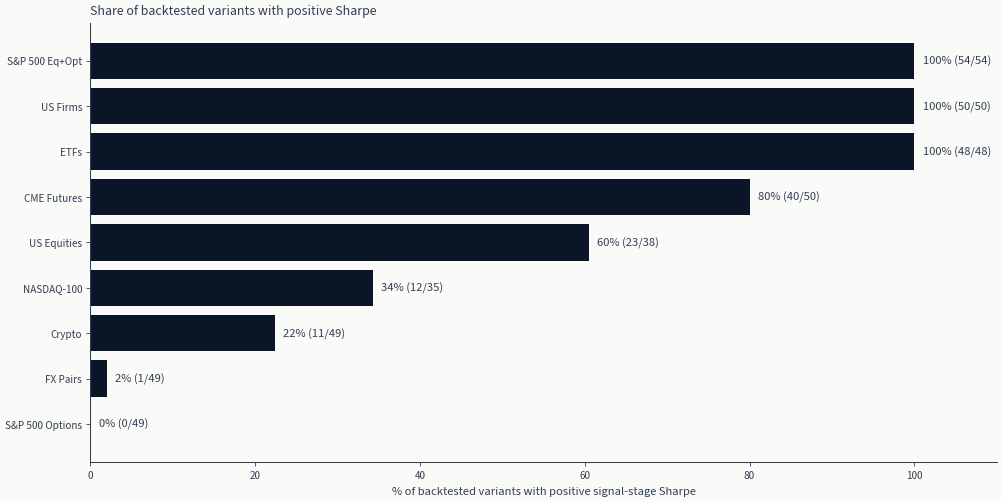

In [17]:
_plotted = variant_stats.filter(pl.col("pct_positive").is_not_null()).sort(
    "pct_positive", descending=True
)
_unmeasured = variant_stats.filter(pl.col("pct_positive").is_null())

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(_plotted["case_study"].to_list(), _plotted["pct_positive"].to_list())
ax.set_xlabel("% of backtested variants with positive signal-stage Sharpe")
ax.set_title("Share of backtested variants with positive Sharpe")
ax.set_xlim(0, 110)
ax.invert_yaxis()
for i, row in enumerate(_plotted.iter_rows(named=True)):
    ax.text(
        row["pct_positive"] + 1,
        i,
        f"{row['pct_positive']:.0f}% ({row['n_positive']}/{row['n_backtested']})",
        va="center",
        fontsize=9,
    )
if _unmeasured.height:
    ax.set_xlabel(
        ax.get_xlabel()
        + "\nnot shown, no backtested variants: "
        + ", ".join(_unmeasured["case_study"].to_list())
    )
show_with_alt(
    fig,
    "Horizontal bars giving, for each case study with backtested variants, the "
    "percentage whose signal-stage Sharpe is positive, annotated with the count "
    "over the number backtested. Case studies with no backtested variants are "
    "named under the axis rather than drawn as zero.",
)

## Key Takeaways

- **IC does not map onto Sharpe by itself.** What sits between them is the
  implementation: the entry scheme, the sizing, the cadence, and the costs. A
  model comparison reported only in IC has not answered what to trade.
- **The IC leader and the Sharpe leader need not be the same family**, and in
  this registry they often are not. The computed count is above; it is small
  enough that it describes these case studies rather than establishing a rule.
- **The selected configuration's Sharpe is the maximum of a sample.** The box plots show the
  distributions those maxima were drawn from, and within one case study the
  spread is wider than the spread of medians across case studies. The Deflated
  Sharpe Ratio exists to discount a maximum for the number of trials behind it.
- **Absence of a measurement is not a measurement of zero.** Four case studies
  have registered predictions and no backtests. They are excluded from the
  rates and named, rather than plotted at zero percent alongside case studies
  that were measured and found wanting.

## Known Limitations

- Five of nine case studies reach the holdout, so every count here is over a
  handful of cases and none of them supports a general claim.
- Cadence is confounded with case study: each cadence in this panel is carried
  by a different set of markets, so the two cannot be separated.
- Validation Sharpe is the selected configuration's own validation number, the
  one it was selected on. Comparing it to the holdout measures selection
  optimism together with whatever genuine decay occurred, and the two are not
  separated here.
- The holdout intervals come from the registry as stored; this notebook does
  not recompute them and inherits whatever bootstrap was used.

**Next**: [`05_portfolio_allocation`](05_portfolio_allocation.ipynb)
compares allocator choices across the case studies;
[`06_cost_survival`](06_cost_survival.ipynb) then analyzes which
strategies survive realistic costs.